## Random Forest Classifier
Random Forest is an ensemble learning algorithm that constructs multiple decision trees during 
training and outputs the final prediction based on majority voting. By aggregating several trees, 
Random Forest reduces overfitting, improves generalisation, and handles non-linear relationships 
effectively, making it suitable for medical classification problems such as diabetes prediction.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

### Data Pre-processing for Random Forest

The same cleaned and pre-processed dataset used in the Decision Tree and SVM experiments was 
applied to the Random Forest model to ensure fair comparison across models.

Physiologically invalid zero values in Glucose, Blood Pressure, and BMI were removed, as these 
represent missing or impossible medical measurements. The Insulin feature was excluded due to a 
high proportion of missing values, which could negatively impact model stability.

Although Random Forest is less sensitive to feature scaling compared to SVM, standardisation was 
still applied to maintain consistency across all models and to support comparison of results.

In [2]:
df = pd.read_csv("data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [9]:
def evaluate_model(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "roc_auc": roc_auc_score(y_true, y_pred),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

In [10]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_baseline.fit(X_train_scaled, y_train)

y_pred_rf_baseline = rf_baseline.predict(X_test_scaled)

rf_baseline_results = evaluate_model(y_test, y_pred_rf_baseline)
rf_baseline_results

{'accuracy': 0.7467532467532467,
 'precision_weighted': 0.7422917218835586,
 'recall_weighted': 0.7467532467532467,
 'f1_weighted': 0.7436948559373376,
 'roc_auc': 0.7112962962962963,
 'confusion_matrix': array([[83, 17],
        [22, 32]])}

In [11]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

In [12]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test_scaled)

rf_smote_results = evaluate_model(y_test, y_pred_rf_smote)
rf_smote_results

{'accuracy': 0.7207792207792207,
 'precision_weighted': 0.7376084589567735,
 'recall_weighted': 0.7207792207792207,
 'f1_weighted': 0.7255589104328599,
 'roc_auc': 0.7168518518518519,
 'confusion_matrix': array([[73, 27],
        [16, 38]])}

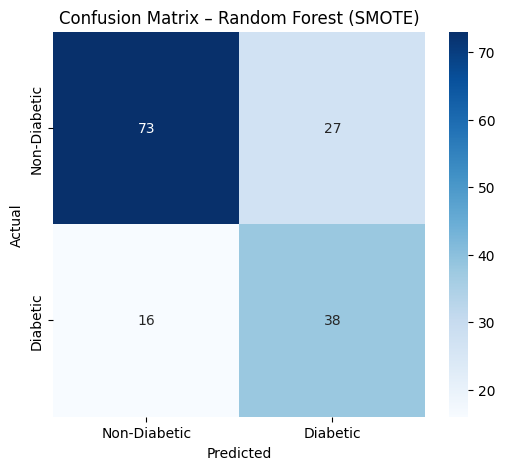

In [13]:
cm = rf_smote_results["confusion_matrix"]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest (SMOTE)")
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

tuned_rf = grid_rf.best_estimator_
y_pred_rf_tuned = tuned_rf.predict(X_test_scaled)

rf_tuned_results = evaluate_model(y_test, y_pred_rf_tuned)

In [15]:
rf_comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Baseline)",
        "Random Forest + SMOTE",
        "Random Forest (Tuned)"
    ],
    "Accuracy": [
        rf_baseline_results["accuracy"],
        rf_smote_results["accuracy"],
        rf_tuned_results["accuracy"]
    ],
    "Precision (Weighted)": [
        rf_baseline_results["precision_weighted"],
        rf_smote_results["precision_weighted"],
        rf_tuned_results["precision_weighted"]
    ],
    "Recall (Weighted)": [
        rf_baseline_results["recall_weighted"],
        rf_smote_results["recall_weighted"],
        rf_tuned_results["recall_weighted"]
    ],
    "F1-Score (Weighted)": [
        rf_baseline_results["f1_weighted"],
        rf_smote_results["f1_weighted"],
        rf_tuned_results["f1_weighted"]
    ],
    "ROC-AUC": [
        rf_baseline_results["roc_auc"],
        rf_smote_results["roc_auc"],
        rf_tuned_results["roc_auc"]
    ]
})

rf_comparison.round(4)

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),ROC-AUC
0,Random Forest (Baseline),0.7468,0.7423,0.7468,0.7437,0.7113
1,Random Forest + SMOTE,0.7208,0.7376,0.7208,0.7256,0.7169
2,Random Forest (Tuned),0.7403,0.7337,0.7403,0.7349,0.6978


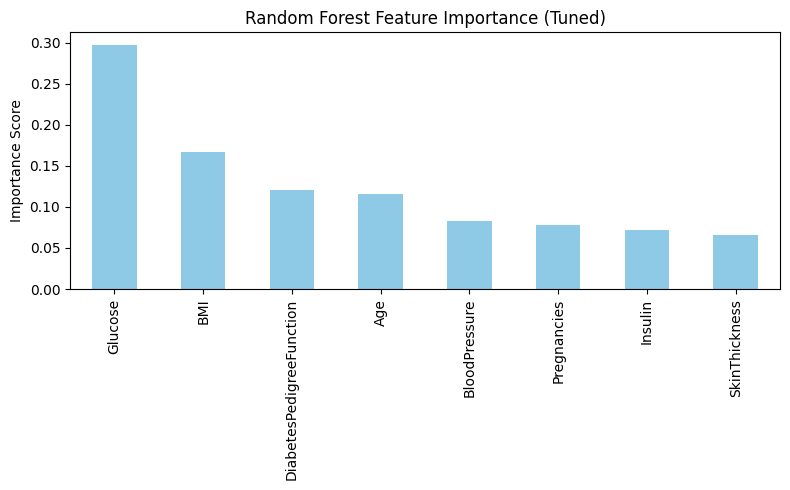

In [17]:
importances = tuned_rf.feature_importances_
features = X.columns

fi = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
fi.plot(kind="bar", color="#8ecae6")
plt.title("Random Forest Feature Importance (Tuned)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

### Interpretation of Random Forest Results

The Random Forest model demonstrates improved robustness compared to single decision trees, as 
reflected in stable accuracy and improved recall when SMOTE is applied. The ensemble approach 
reduces overfitting and enhances the model’s ability to generalise to unseen data.

The SMOTE-enhanced Random Forest increases sensitivity toward the minority diabetic class, reducing 
the number of false negatives observed in the baseline model. This improvement highlights the 
importance of addressing class imbalance in medical datasets.

### Medical Relevance

From a clinical perspective, Random Forest provides a reliable diagnostic support model due to its 
ability to capture complex interactions between physiological variables such as glucose levels, BMI, 
and age.

The application of SMOTE improves the detection of diabetic patients, which is critical in reducing 
missed diagnoses. Early identification of diabetes allows for timely intervention, lifestyle 
modifications, and medical treatment, significantly lowering the risk of long-term complications.
Therefore, Random Forest combined with imbalance-handling techniques represents a strong candidate 
for decision-support systems in healthcare.